# Stage 1 ABM — Diagnostic Analysis
ZI-only LOB. Checks: price dynamics, spread, depth, volume, and fundamental tracking.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('output/stage1_run.csv')
df['ret'] = df['mid_price'].pct_change()
df['log_ret'] = np.log(df['mid_price']).diff()
df.head()

,t,mid_price,spread,bid_depth,ask_depth,volume,fundamental,ret,log_ret
0,0,NaN,NaN,0,0,0,450.0,NaN,NaN
1,1,450.000,0.02,9,1,0,450.0,NaN,NaN
2,2,449.995,0.01,0,12,0,450.0,-0.000011,-0.000011
3,3,449.995,0.01,7,10,0,450.0,0.000000,0.000000
4,4,449.995,0.01,2,3,0,450.0,0.000000,0.000000


## 1. Price Path and Fundamental
Does mid-price track the fundamental? In ZI-only LOB the fundamental is exogenous; price should track it loosely.
If fundamental is flat the process is not wired into the simulation loop.

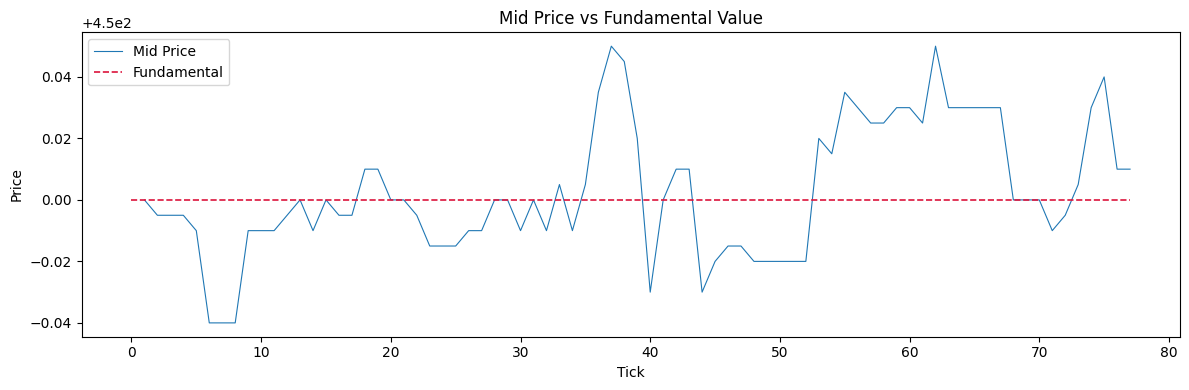

Fundamental std: 0.0000  — expect > 0 once GBM process is wired in


In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['t'], df['mid_price'], lw=0.8, label='Mid Price')
ax.plot(df['t'], df['fundamental'], lw=1.2, ls='--', color='crimson', label='Fundamental')
ax.set_xlabel('Tick'); ax.set_ylabel('Price')
ax.set_title('Mid Price vs Fundamental Value')
ax.legend(); plt.tight_layout(); plt.show()

fund_std = df['fundamental'].std()
print(f'Fundamental std: {fund_std:.4f}  — expect > 0 once GBM process is wired in')

## 2. Return Distribution
Key stylised facts (Cont 2001, Gao et al. 2022): fat tails (excess kurtosis > 0), near-zero raw return ACF,
positive |return| ACF (volatility clustering). ZI-only models typically lack clustering — expected at Stage 1.

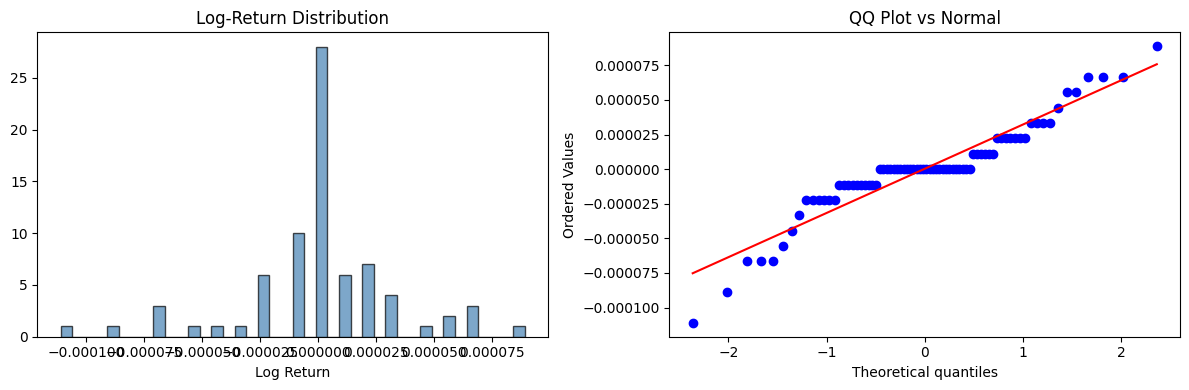

Mean:     0.000000
Std:      0.000033
Skewness: -0.4380  (target ≈ 0)
Kurtosis: 2.2342  (excess; target > 0 for fat tails)


In [21]:
rets = df['log_ret'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rets, bins=40, edgecolor='k', color='steelblue', alpha=0.7)
axes[0].set_title('Log-Return Distribution'); axes[0].set_xlabel('Log Return')
stats.probplot(rets, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot vs Normal')
plt.tight_layout(); plt.show()

print(f'Mean:     {rets.mean():.6f}')
print(f'Std:      {rets.std():.6f}')
print(f'Skewness: {rets.skew():.4f}  (target ≈ 0)')
print(f'Kurtosis: {rets.kurt():.4f}  (excess; target > 0 for fat tails)')

## 3. Autocorrelation Structure
Raw return ACF ≈ 0 for lag > 0; |return| ACF positive and slowly decaying (Cont 2001).
Absence of volatility clustering at Stage 1 is expected and motivates adding structured traders in Stage 2.

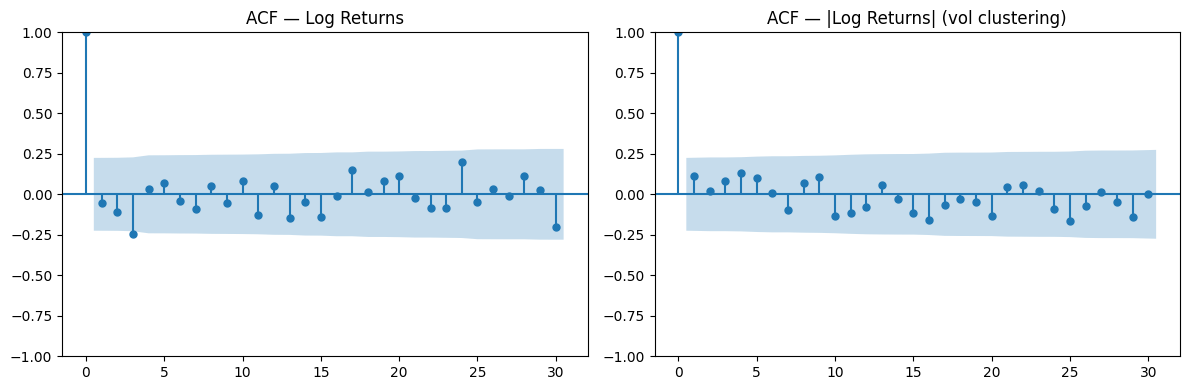

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(rets, lags=30, ax=axes[0], title='ACF — Log Returns')
plot_acf(rets.abs(), lags=30, ax=axes[1], title='ACF — |Log Returns| (vol clustering)')
plt.tight_layout(); plt.show()

## 4. Spread Diagnostics
Spread should be positive and non-trivial. Cont & Stoikov (2008) relate the equilibrium spread to order
arrival rates: spread ≈ (δ/μ) × log(1 + μ/λ). An empty spread column means the market engine
is not recording best bid/ask after the call-auction match.

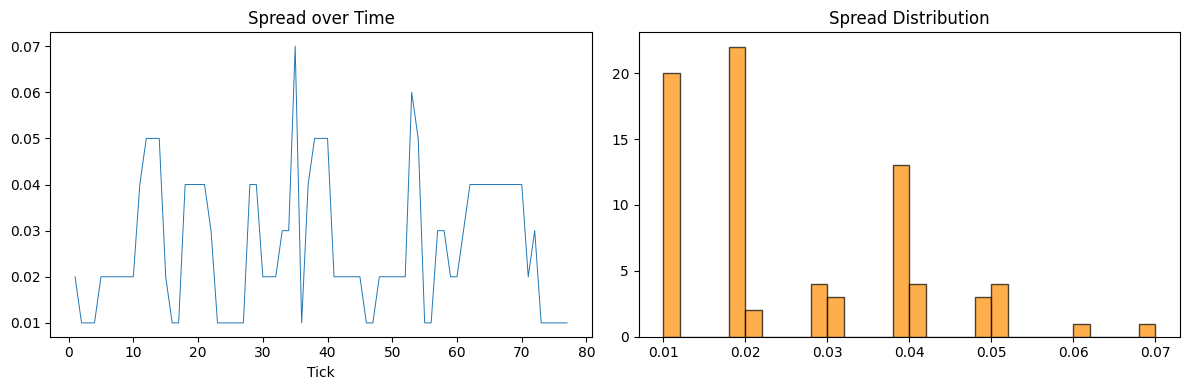

Mean spread: 0.0266, Std: 0.0147


In [23]:
spread_valid = df['spread'].dropna()
if len(spread_valid) == 0:
    print('ISSUE: spread column is entirely empty — bid/ask not being recorded after match.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df['t'], df['spread'], lw=0.7)
    axes[0].set_title('Spread over Time'); axes[0].set_xlabel('Tick')
    axes[1].hist(spread_valid, bins=30, edgecolor='k', color='darkorange', alpha=0.7)
    axes[1].set_title('Spread Distribution')
    plt.tight_layout(); plt.show()
    print(f'Mean spread: {spread_valid.mean():.4f}, Std: {spread_valid.std():.4f}')

## 5. Order Book Depth
Bid and ask depth should be roughly balanced on average under symmetric ZI order flow (Farmer et al. 2005).
Persistent one-sided depth signals asymmetric order generation or orders not expiring correctly.

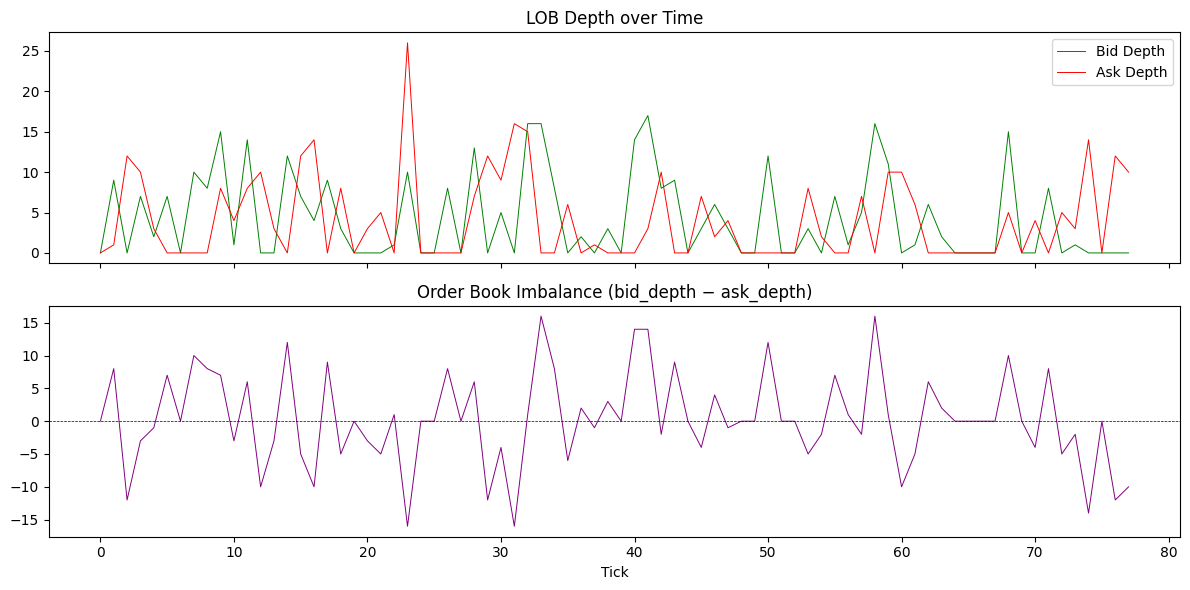

Mean bid depth: 4.33
Mean ask depth: 4.04
Mean imbalance: 0.29  (target ≈ 0 for symmetric ZI)


In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df['t'], df['bid_depth'], lw=0.7, color='green', label='Bid Depth')
axes[0].plot(df['t'], df['ask_depth'], lw=0.7, color='red', label='Ask Depth')
axes[0].set_title('LOB Depth over Time'); axes[0].legend()
axes[1].plot(df['t'], df['bid_depth'] - df['ask_depth'], lw=0.7, color='purple')
axes[1].axhline(0, ls='--', color='k', lw=0.5)
axes[1].set_title('Order Book Imbalance (bid_depth − ask_depth)')
axes[1].set_xlabel('Tick')
plt.tight_layout(); plt.show()

print(f'Mean bid depth: {df["bid_depth"].mean():.2f}')
print(f'Mean ask depth: {df["ask_depth"].mean():.2f}')
print(f'Mean imbalance: {(df["bid_depth"] - df["ask_depth"]).mean():.2f}  (target ≈ 0 for symmetric ZI)')

## 6. Volume
Volume should be positive and variable. Zero-volume ticks indicate no matches occurred —
either the book was empty on one side or all orders expired before matching.

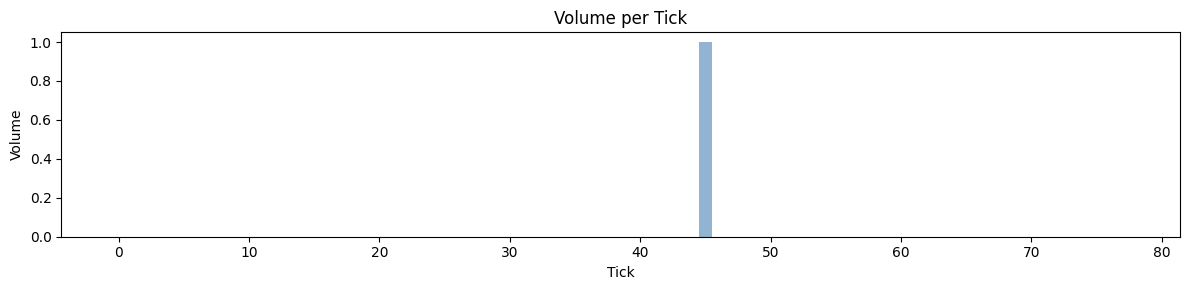

Zero-volume ticks: 98.7%  (if high, book is too thin or order rates too low)


In [25]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(df['t'], df['volume'], width=1, color='steelblue', alpha=0.6)
ax.set_title('Volume per Tick'); ax.set_xlabel('Tick'); ax.set_ylabel('Volume')
plt.tight_layout(); plt.show()

zero_vol_pct = (df['volume'] == 0).mean() * 100
print(f'Zero-volume ticks: {zero_vol_pct:.1f}%  (if high, book is too thin or order rates too low)')

## 7. Price Grid Concentration
Number of distinct price levels indicates LOB granularity. Very few levels (< 10) means
tick size is too coarse relative to the initial price, or ZI price offsets are too wide.
For E-mini-like instruments, tick_size = 0.25 with delta ≈ 0.001 gives ~4-5 tick spreads.

Distinct mid-price levels visited: 17
mid_price
449.960     3
449.970     2
449.980     6
449.985     5
449.990    11
449.995     8
450.000    12
450.005     3
450.010     6
450.015     1
450.020     2
450.025     3
450.030     9
450.035     2
450.040     1
450.045     1
450.050     2
Name: count, dtype: int64


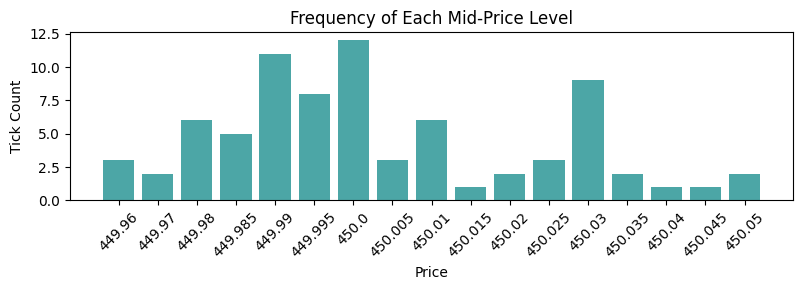

In [26]:
price_counts = df['mid_price'].value_counts().sort_index()
print(f'Distinct mid-price levels visited: {len(price_counts)}')
print(price_counts)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(price_counts.index.astype(str), price_counts.values, color='teal', alpha=0.7)
ax.set_title('Frequency of Each Mid-Price Level')
ax.set_xlabel('Price'); ax.set_ylabel('Tick Count')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 8. Summary Diagnostics
Consolidated checklist of known issues to address before Stage 2.

In [27]:
issues = []

if df['fundamental'].std() < 1e-6:
    issues.append('FAIL  fundamental process is static — GBM not wired into simulation loop')
else:
    issues.append('OK    fundamental process is dynamic')

if df['spread'].isna().all():
    issues.append('FAIL  spread not recorded — market engine not writing bid/ask after match')
else:
    issues.append('OK    spread recorded')

n_prices = df['mid_price'].nunique()
if n_prices < 10:
    issues.append(f'WARN  only {n_prices} distinct price levels — tick size likely too coarse for P0={df["mid_price"].iloc[0]:.0f}')
else:
    issues.append(f'OK    {n_prices} distinct price levels')

zero_vol = (df['volume'] == 0).mean()
if zero_vol > 0.3:
    issues.append(f'WARN  {zero_vol*100:.0f}% of ticks have zero volume — book too thin or order rates too low')
else:
    issues.append(f'OK    zero-volume ticks: {zero_vol*100:.0f}%')

imbalance = abs((df['bid_depth'] - df['ask_depth']).mean())
if imbalance > 2:
    issues.append(f'WARN  mean book imbalance = {imbalance:.2f} — order flow not symmetric')
else:
    issues.append(f'OK    book imbalance ≈ {imbalance:.2f}')

for line in issues:
    print(line)

FAIL  fundamental process is static — GBM not wired into simulation loop
OK    spread recorded
OK    17 distinct price levels
WARN  99% of ticks have zero volume — book too thin or order rates too low
OK    book imbalance ≈ 0.29
